# День 08. Упражнение 04
# Регрессия

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## 1. Предобработка

1. Прочитай файл [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Заполни пропущенные значения нулями (`0`).
3. Раздели набор данных на обучающую и тестовую выборки с параметрами `test_size=0.2`.

In [2]:
df = pd.read_csv('../data/checker_regression.csv')

In [3]:
df = df.groupby('uid').agg({
    'num_commits': 'first',
    'pageviews': 'first',
    'AVG(diff)': 'mean'
}).reset_index(drop=True)

In [4]:
df = df.fillna(0)

In [5]:
print(df[['num_commits', 'pageviews', 'AVG(diff)']].info())

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 828.0 bytes
None


In [6]:
X = df[['num_commits', 'pageviews']].values
y = df['AVG(diff)'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

## 2. Кросс-валидация

1. Напиши функцию `crossval`, которая принимает аргументы: `n_splits` для `KFold()`, `X`, `y`, модель (инициализированный класс с параметрами модели; не забудь о `random_state=21`) и возвращает для данного класса модели результат в таком виде:

```
train - 2696.4496895424836 | test - 1589.9979527104958
train - 2660.957874001452 | test - 2075.102636027137
train - 2847.315529246795 | test - 320.911928168403
train - 2500.7691099659237 | test - 4132.461382030178
train - 2643.927917295123 | test - 2237.8140952197878
train - 2396.295678819444 | test - 4509.650064742476
train - 2003.402267924976 | test - 8403.491474908551
train - 2531.876094212613 | test - 3135.944102735099
train - 2683.1795186023123 | test - 1796.01426292594
train - 2537.1192483996338 | test - 3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Запусти функцию для моделей `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. Параметры можешь выбрать самостоятельно, но тщательно убедись, что они подходят.

In [7]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    test_rmses = []
    for train_idx, test_idx in kf.split(X):
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]
        model_clone = model.__class__(**model.get_params())
        if hasattr(model_clone, 'random_state'):
            model_clone.set_params(random_state=21)
        model_clone.fit(X_train_fold, y_train_fold)
        train_rmse = np.sqrt(mean_squared_error(y_train_fold, model_clone.predict(X_train_fold)))
        test_rmse = np.sqrt(mean_squared_error(y_test_fold, model_clone.predict(X_test_fold)))
        test_rmses.append(test_rmse)
        print(f'train - {train_rmse} | test - {test_rmse}')
    print(f'Average RMSE on crossval is {np.mean(test_rmses)}')

In [8]:
print('LinearRegression:')
crossval(10, X, y, LinearRegression())

LinearRegression:
train - 61.35327112662008 | test - 57.85614740884658
train - 62.5462335194863 | test - 44.71218893425673
train - 61.14556371253599 | test - 83.19897138394585
train - 58.416728626194235 | test - 79.399015977114
train - 60.11026827841826 | test - 68.75614618929599
train - 60.619323028395335 | test - 65.92296908962915
train - 61.72075104991357 | test - 61.8003605530157
train - 62.60680682836641 | test - 46.68994292992783
train - 55.58034321272078 | test - 99.08124434288634
train - 61.57793245106181 | test - 53.24118830442656
Average RMSE on crossval is 66.06581751133447


In [9]:
print('DecisionTreeRegressor:')
crossval(10, X, y, DecisionTreeRegressor(random_state=21))

DecisionTreeRegressor:
train - 0.0 | test - 117.17718934888181
train - 0.0 | test - 79.5333147061541
train - 0.0 | test - 0.0
train - 0.0 | test - 78.98656472722058
train - 0.0 | test - 101.36705213854874
train - 0.0 | test - 35.38836908740875
train - 0.0 | test - 0.0
train - 0.0 | test - 69.81014730443323
train - 0.0 | test - 117.52949078296776
train - 0.0 | test - 40.58792924010783
Average RMSE on crossval is 64.03800573357229


In [10]:
print('RandomForestRegressor:')
crossval(10, X, y, RandomForestRegressor(random_state=21))

RandomForestRegressor:
train - 20.920695939881494 | test - 97.50335139862099
train - 22.513709875327706 | test - 78.01690371916807
train - 26.45753874793136 | test - 20.678674351271315
train - 24.801579078915356 | test - 56.688591592495406
train - 22.400454654459477 | test - 77.74492463343996
train - 23.84950304426348 | test - 53.93331786876579
train - 24.960042347292447 | test - 8.141221739804578
train - 24.33125738694806 | test - 57.41679402832187
train - 21.748562307626617 | test - 91.24344940546369
train - 26.400345641306533 | test - 32.155805517822095
Average RMSE on crossval is 57.35230342551737


## 3. Предсказания и оценка

1. Сделай предсказания на тестовом наборе данных для каждой из трёх моделей с финальными параметрами.
2. Построй график для каждой модели, где по оси x — фактическая средняя разница, а по оси y — предсказание модели.
3. Как должен выглядеть график в идеальном случае? Напиши ответ в markdown-ячейке в конце раздела.

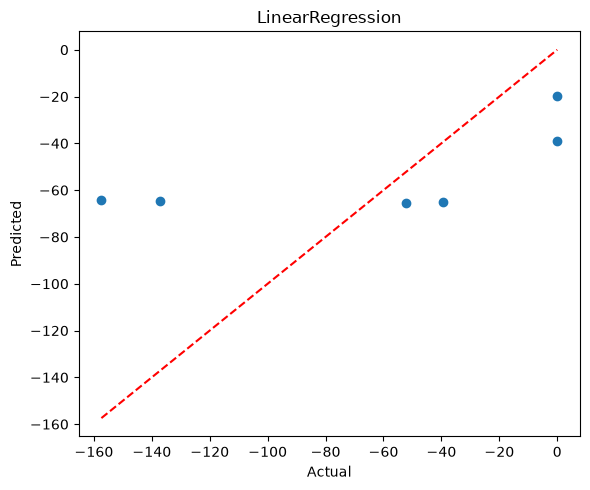

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('LinearRegression')
plt.tight_layout()
plt.show()

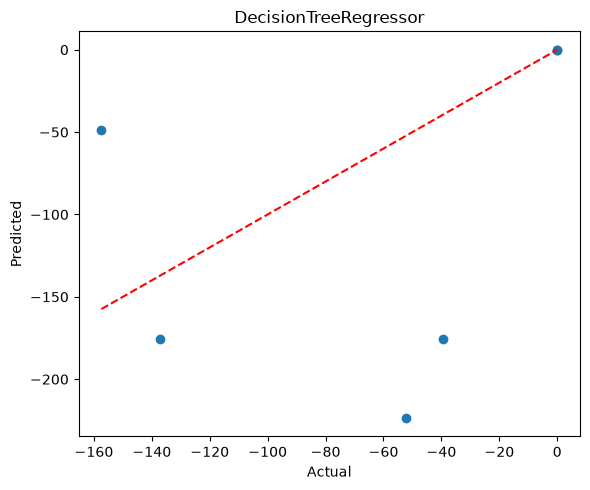

In [12]:
dtr = DecisionTreeRegressor(random_state=21)
dtr.fit(X_train, y_train)
pred_dtr = dtr.predict(X_test)
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_dtr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('DecisionTreeRegressor')
plt.tight_layout()
plt.show()

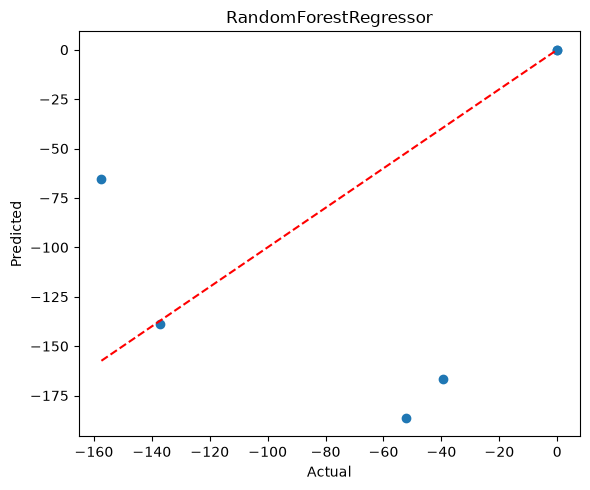

In [13]:
rfr = RandomForestRegressor(random_state=21)
rfr.fit(X_train, y_train)
pred_rfr = rfr.predict(X_test)
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_rfr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('RandomForestRegressor')
plt.tight_layout()
plt.show()

a diagonal